In [1]:
import numpy as np
import networkx as nx

from scipy.integrate import solve_ivp
import importlib
import replicator_net
importlib.reload(replicator_net)
from replicator_net import ODReplicatorNetwork


In [2]:
# Simulation: fetch a real spatial graph via OSMnx (no grid fallback)
import sys, os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
np.random.seed(42)

# ensure we can import the local module
sys.path.append(os.path.dirname(__file__) if '__file__' in globals() else '.')
sys.path.append('')
from replicator_net import ODReplicatorNetwork

# Require OSMnx to fetch a real spatial graph. Try cache first, then place, then point.
try:
    import osmnx as ox
except Exception as e:
    raise RuntimeError("OSMnx is required to fetch a real spatial graph. Install `osmnx` and ensure network access.") from e

use_graph = None
cache_dir = os.path.join(os.path.dirname(__file__) if '__file__' in globals() else '.', 'cache')
os.makedirs(cache_dir, exist_ok=True)
graph_cache_path = os.path.join(cache_dir, 'vatican_city_drive.graphml')
if os.path.exists(graph_cache_path):
    try:
        G_drive = ox.load_graphml(graph_cache_path)
        G = nx.convert_node_labels_to_integers(nx.Graph(G_drive), label_attribute='original_node_id')
        use_graph = G
        print('Loaded cached graph from:', graph_cache_path)
    except Exception as cache_err:
        print('Cached graph load failed, refetching:', cache_err)
place = 'Vatican City, Vatican'
if use_graph is None:
    try:
        G_drive = ox.graph_from_place(place, network_type='drive', simplify=True)
        # convert to undirected using networkx to support different osmnx versions
        G = nx.convert_node_labels_to_integers(nx.Graph(G_drive), label_attribute='original_node_id')
        use_graph = G
        ox.save_graphml(G_drive, graph_cache_path)
        print('Fetched graph from OSMnx for:', place)
        print('Saved graph cache to:', graph_cache_path)
    except Exception as e1:
        print('graph_from_place failed:', e1)
        # try fetching by coordinates (Vatican City approx)
        try:
            lat, lon = 41.9029, 12.4534
            G_drive = ox.graph_from_point((lat, lon), dist=1000, network_type='drive', simplify=True)
            G = nx.convert_node_labels_to_integers(nx.Graph(G_drive), label_attribute='original_node_id')
            use_graph = G
            ox.save_graphml(G_drive, graph_cache_path)
            print(f'Fetched graph from OSMnx around point ({lat},{lon})')
            print('Saved graph cache to:', graph_cache_path)
        except Exception as e2:
            raise RuntimeError('OSMnx failed to fetch a real graph for the requested place/point. Check network or try a different place.') from e2

G = use_graph

def _node_xy(data):
    if 'x' in data and 'y' in data:
        return float(data['x']), float(data['y'])
    if 'lon' in data and 'lat' in data:
        return float(data['lon']), float(data['lat'])
    coord = data.get('coord')
    if isinstance(coord, (tuple, list, np.ndarray)) and len(coord) >= 2:
        return float(coord[0]), float(coord[1])
    return 0.0, 0.0

pos = {n: _node_xy(data) for n, data in G.nodes(data=True)}
edges = list(G.edges())
E = len(edges)
print(f'Nodes: {G.number_of_nodes()}, Edges: {E}')

# Build multilayer graphs (same street graph for 3 modes)
graphs = [G.copy(), G.copy(), G.copy()]
mode_names = ['car', 'bike', 'transit']
K = len(mode_names)

# Edge lengths: use 'length' attribute if present, else euclidean distance from node coords
lengths = np.zeros(E)
coords = {n: np.array(pos[n], dtype=float) for n in G.nodes()}
for i, (u, v) in enumerate(edges):
    data = G.get_edge_data(u, v) or {}
    if isinstance(data, dict) and 'length' in data:
        lengths[i] = data['length'] if not isinstance(data['length'], dict) else float(list(data['length'].values())[0])
    else:
        lengths[i] = np.linalg.norm(coords[u] - coords[v]) + 1e-6

# capacities and speeds [UNITS: lengths in meters, speeds in m/s, capacities in vehicles]
n_lanes = np.random.randint(1, 2, size=E)
vehicle_length = 5.0  # meters
transit_vehicle_length = 10.0  # meters
bike_length = 2.0  # meters

# Mode-dependent capacities: vehicles per edge per mode
capacities_car = lengths * n_lanes / vehicle_length
capacities_bike = lengths * n_lanes / bike_length
capacities_transit = lengths * n_lanes / transit_vehicle_length
capacities = np.column_stack([capacities_car, capacities_bike, capacities_transit])  # shape (E,K)

car_speed = np.full(E, 50.0 / 3.6)  # 50 km/h → m/s
bike_speed = np.full(E, 12.0 / 3.6)  # 12 km/h → m/s
transit_speed = np.full(E, 25.0 / 3.6)  # 25 km/h → m/s
free_flow_speeds = np.column_stack([car_speed, bike_speed, transit_speed])  # shape (E,K)

interaction_matrix = np.array([
    [60.0,  5.0, 10.0],   # impact on su car from [car, bike, transit] (s per unit density)
    [ 2.0, 10.0,  3.0],   # impact on bike
    [20.0,  5.0, 30.0],   # impact on transit
])

# pick a small set of zones from graph nodes
nodes = list(G.nodes())
if len(nodes) <= 6:
    zones = nodes
else:
    zones = list(np.random.choice(nodes, size=15, replace=False))
print('Zones:', zones)

# build model
model = ODReplicatorNetwork(
    multilayer_graphs=graphs,
    zones=zones,
    edge_lengths=lengths,
    edge_capacities=capacities,
    free_flow_speeds=free_flow_speeds,
    rho=0.01,
    interaction_matrix=interaction_matrix,
    od_demands=np.random.uniform(1, 1, size=(len(zones) * (len(zones) - 1),))
)

initialization_method = 'uniform'  # options: 'random', 'uniform', 'custom'

if initialization_method == 'uniform':
    x0 = np.full((model.N_od, model.K), 1.0 / model.K)

elif initialization_method == 'custom':
    x0 = np.zeros((model.N_od, model.K))
    for od in range(model.N_od):
        x0[od, od % model.K] = 1.0  # assign each OD to a single mode in round-robin fashion
else:
    # random initial shares per OD, row-normalized
    x0 = np.random.rand(model.N_od, model.K)

x0 = x0 / x0.sum(axis=1, keepdims=True)
print(f'Running simulation... (N_od={model.N_od}, K={model.K})')

t, X = model.simulate(x0, t_span=(0, 200), n_steps=400)

print('Simulation finished. t points:', len(t))

# summary outputs
x_final = X[-1]
mode_history = X.mean(axis=1)
print('\nFinal average modal shares:')
for m, name in enumerate(mode_names):
    print(f'{name}: {mode_history[-1, m]:.4f}')

# compute final aggregate flows per edge
final_mode_flows = np.zeros((model.E, model.K))
for od in range(model.N_od):
    for m in range(model.K):
        share = x_final[od, m]
        path = model.paths[(od, m)]
        for e in path:
            final_mode_flows[e, m] += share
agg_flows = final_mode_flows.sum(axis=1)
top_idx = np.argsort(agg_flows)[-5:][::-1]
print('\nTop edges by final aggregate share:')
for idx in top_idx:
    print(f'edge {edges[idx]} -> flow {agg_flows[idx]:.4f}')

# save modal history
try:
    import matplotlib
    matplotlib.use('Agg')
    plt.figure(figsize=(6,4))
    for m in range(model.K):
        plt.plot(t, X[:, :, m].mean(axis=1), label=mode_names[m])
    plt.xlabel('time')
    plt.ylabel('avg modal share')
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.savefig('small_city_sim_modal_history.png')
    print('\nSaved modal history to small_city_sim_modal_history.png')
except Exception:
    pass


graph_from_place failed: Nominatim did not geocode query 'Vatican City, Vatican' to a geometry of type (Multi)Polygon.
Fetched graph from OSMnx around point (41.9029,12.4534)
Saved graph cache to: ./cache/vatican_city_drive.graphml
Nodes: 510, Edges: 743
Zones: [np.int64(480), np.int64(449), np.int64(475), np.int64(434), np.int64(368), np.int64(55), np.int64(322), np.int64(76), np.int64(504), np.int64(347), np.int64(415), np.int64(220), np.int64(117), np.int64(249), np.int64(173)]
Running simulation... (N_od=210, K=3)
solve_ivp success: True
message: The solver successfully reached the end of the integration interval.
Simulation finished. t points: 400

Final average modal shares:
car: 0.2179
bike: 0.6857
transit: 0.0964

Top edges by final aggregate share:
edge (180, 186) -> flow 64.0000
edge (144, 433) -> flow 56.0000
edge (140, 433) -> flow 56.0000
edge (140, 180) -> flow 56.0000
edge (13, 504) -> flow 48.0000

Saved modal history to small_city_sim_modal_history.png


Selected OD index: 78 / 209


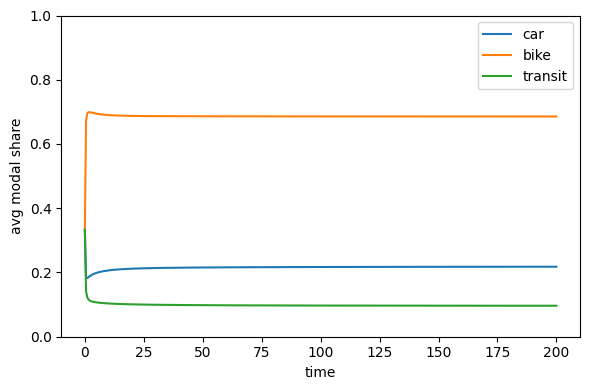

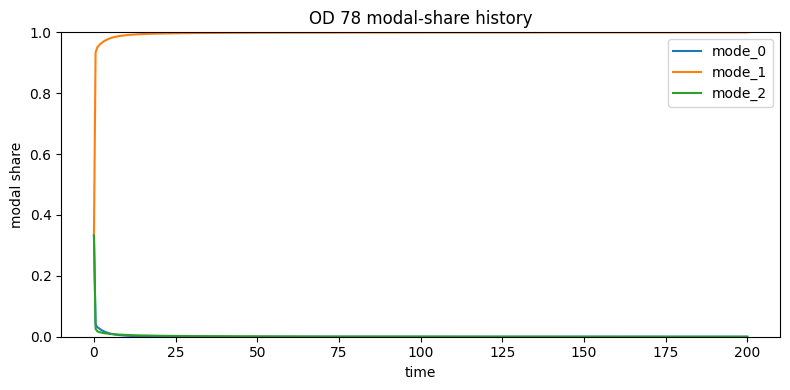

  mode_0: 0.0000
  mode_1: 0.9999
  mode_2: 0.0001
  mode 0: [151, 152, 59, 58, 259, 129, 128, 704, 275, 269, 270, 338, 341, 328, 329, 416, 115, 114, 116, 427, 730, 473, 472, 64, 20, 19, 73, 75, 398, 400, 623, 33, 31, 645]
  mode 1: [151, 152, 59, 58, 259, 129, 128, 704, 275, 269, 270, 338, 341, 328, 329, 416, 115, 114, 116, 427, 730, 473, 472, 64, 20, 19, 73, 75, 398, 400, 623, 33, 31, 645]
  mode 2: [151, 152, 59, 58, 259, 129, 128, 704, 275, 269, 270, 338, 341, 328, 329, 416, 115, 114, 116, 427, 730, 473, 472, 64, 20, 19, 73, 75, 398, 400, 623, 33, 31, 645]


In [3]:
# Plot and display the full modal-share history for one random OD
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

# Ensure the simulation variables exist
if 't' not in globals() or 'X' not in globals() or 'model' not in globals():
    raise RuntimeError('Run the simulation cell first to define `t`, `X`, and `model`.')

od_idx = int(np.random.randint(0, model.N_od))
print(f'Selected OD index: {od_idx} / {model.N_od - 1}')

# Plot modal share history for that OD
mode_names = ['car', 'bike', 'transit'] if not hasattr(model, 'K') else [f'mode_{i}' for i in range(model.K)]
fig, ax = plt.subplots(figsize=(8,4))
for m in range(model.K):
    ax.plot(t, X[:, od_idx, m], label=(mode_names[m] if m < len(mode_names) else f'mode_{m}'))
ax.set_xlabel('time')
ax.set_ylabel('modal share')
ax.set_ylim(0,1)
ax.set_title(f'OD {od_idx} modal-share history')
ax.legend()
plt.tight_layout()
plt.show()

# Also print the final modal shares and the paths used by this OD for each mode
x_final = X[-1]

for m in range(model.K):
    print(f'  {mode_names[m] if m < len(mode_names) else f"mode_{m}"}: {x_final[od_idx, m]:.4f}')

for m in range(model.K):
    path = model.paths.get((od_idx, m), None)
    print(f'  mode {m}:', path)

In [4]:
# Spatial graph visualization with per-mode flows
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

mode_names = ['car', 'bike', 'transit']
if 'model' not in globals() or 'X' not in globals() or 'edges' not in globals() or 'pos' not in globals():
    raise RuntimeError('Please run the simulation cell above before plotting (defines model, X, edges, pos).')

x_final = X[-1]

def _as_xy(value):
    if isinstance(value, (list, tuple, np.ndarray)) and len(value) >= 2:
        return float(value[0]), float(value[1])
    if isinstance(value, dict):
        if 'x' in value and 'y' in value:
            return float(value['x']), float(value['y'])
        if 'lon' in value and 'lat' in value:
            return float(value['lon']), float(value['lat'])
    return 0.0, 0.0

pos = {n: _as_xy(v) for n, v in pos.items()}

# final flow on each edge, per mode
final_mode_flows = np.zeros((model.E, model.K))
for od in range(model.N_od):
    for m in range(model.K):
        share = float(x_final[od, m])
        for e in model.paths[(od, m)]:
            final_mode_flows[e, m] += share

# extent for a nicer map-like layout
xy = np.array([pos[n] for n in G.nodes()], dtype=float)
min_x, min_y = xy.min(axis=0)
max_x, max_y = xy.max(axis=0)
span = max(max_x - min_x, max_y - min_y)
pad = 0.05 * span if span > 0 else 1.0

# Get zone indices for highlighting
zone_indices = np.array([list(G.nodes()).index(z) for z in model.zones])
all_indices = np.arange(len(G.nodes()))
non_zone_indices = np.array([i for i in all_indices if i not in zone_indices])

fig, axes = plt.subplots(1, model.K, figsize=(5 * model.K, 6), squeeze=False)
axes = axes.ravel()

for m, ax in enumerate(axes):
    segments = []
    widths = []
    colors = []
    flows = final_mode_flows[:, m]
    vmax = float(flows.max()) if flows.max() > 0 else 1.0
    cmap = plt.cm.viridis
    for i, (u, v) in enumerate(edges):
        x0, y0 = pos.get(u, (0.0, 0.0))
        x1, y1 = pos.get(v, (0.0, 0.0))
        segments.append([(x0, y0), (x1, y1)])
        frac = flows[i] / vmax
        widths.append(0.5 + 6.0 * frac)
        colors.append(cmap(frac))

    lc = LineCollection(segments, colors=colors, linewidths=widths, alpha=0.9)
    ax.add_collection(lc)
    
    # Plot non-zone nodes in black
    if len(non_zone_indices) > 0:
        ax.scatter(xy[non_zone_indices, 0], xy[non_zone_indices, 1], s=8, c='black', alpha=0.75, zorder=3)
    
    # Plot zone nodes (OD couples) in red
    if len(zone_indices) > 0:
        ax.scatter(xy[zone_indices, 0], xy[zone_indices, 1], s=80, c='red', alpha=0.9, zorder=4, edgecolors='darkred', linewidth=1.5)
    
    ax.set_title(mode_names[m] if m < len(mode_names) else f'mode {m}')
    ax.set_xlim(min_x - pad, max_x + pad)
    ax.set_ylim(min_y - pad, max_y + pad)
    ax.set_aspect('equal')
    ax.set_axis_off()

plt.tight_layout()
outfn = 'small_city_flows_by_mode.png'
plt.savefig(outfn, dpi=180, bbox_inches='tight')
print(f'Saved {outfn}')


Saved small_city_flows_by_mode.png


In [5]:
# Plot modal share percentage as a function of distance between OD pairs
import numpy as np
import matplotlib.pyplot as plt

# Ensure variables are available
if 't' not in globals() or 'X' not in globals() or 'model' not in globals():
    raise RuntimeError('Run the simulation cell first to define `t`, `X`, and `model`.')

x_final = X[-1]
mode_names = ['car', 'bike', 'transit']

# Use network distance in meters (shortest path length on the street graph)
# This is more meaningful than raw x/y coordinates, which may be in degrees.
od_distances = []
od_modal_shares = [[] for _ in range(model.K)]

od_idx = 0
for i, origin in enumerate(model.zones):
    for j, dest in enumerate(model.zones):
        if i == j:
            continue

        try:
            # Shortest path distance using edge lengths in meters
            distance_m = nx.shortest_path_length(G, origin, dest, weight='length')
        except Exception:
            # Fallback: sum the stored edge lengths along the mode-0 path
            path_edges = model.paths[(od_idx, 0)]
            distance_m = float(np.sum(lengths[path_edges]))

        od_distances.append(distance_m)
        for m in range(model.K):
            od_modal_shares[m].append(float(x_final[od_idx, m]) * 100.0)
        od_idx += 1

od_distances = np.asarray(od_distances)
for m in range(model.K):
    od_modal_shares[m] = np.asarray(od_modal_shares[m])

# Create scatter plot with mode colors
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red', 'green', 'blue']
labels = ['car', 'bike', 'transit']

for m in range(model.K):
    ax.scatter(
        od_distances,
        od_modal_shares[m],
        c=colors[m],
        label=labels[m],
        s=80,
        alpha=0.6,
        edgecolors='black',
    )

ax.set_xlabel('Distance between OD pair (meters)', fontsize=12)
ax.set_ylabel('Modal Share (%)', fontsize=12)
ax.set_title('Modal Share vs Distance between OD Pairs', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('modal_share_vs_distance.png', dpi=180, bbox_inches='tight')
plt.show()

print('Distance stats (meters):')
print(f'min = {od_distances.min():.2f}, mean = {od_distances.mean():.2f}, max = {od_distances.max():.2f}')
print('Distribution of modal shares by distance:')
for m in range(model.K):
    mask = od_modal_shares[m] > 0
    if mask.sum() > 0:
        mean_dist = od_distances[mask].mean()
        mean_share = od_modal_shares[m][mask].mean()
        print(f'{labels[m]}: avg share = {mean_share:.2f}%, avg distance = {mean_dist:.2f}m')


Distance stats (meters):
min = 75.30, mean = 1557.03, max = 2907.30
Distribution of modal shares by distance:
car: avg share = 25.71%, avg distance = 1513.04m
bike: avg share = 74.22%, avg distance = 1568.21m
transit: avg share = 11.64%, avg distance = 1516.58m


/tmp/ipykernel_52230/831166081.py:63: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
